In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from analysis_by_plot import draw_floorplan

In [2]:
n_trial = 10
ls_var = 'x', 'y', 'f'
model_names = 'MB4ONaxial', 'MB4ONdiagonal', 'MB2ONbilateral', 'MB2ONopponent'
# for robot_id in (1, 2):
#     for mn in model_names:
#         model_name = '{}{}'.format(mn, robot_id)
#         alldata[model_name] = {}
# ls_color = 'rb'

In [3]:
# record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/2robot-collision/'
# # demo_id = 'demo_20240826_2'

repeat = 50

record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/tworobots/'
ls_record = np.sort(os.listdir(record_dir))[:repeat * 2]

repeatdata = []

for trial_id in range(len(ls_record) // 2):
    alldata = {}
    folder1 = ls_record[trial_id * 2]
    folder2 = ls_record[trial_id * 2 + 1]
    for robot_id, fld in zip((1, 2), (folder1, folder2)):
        data_dir = os.path.join(record_dir, fld)
        for mn in model_names:
            model_name = '{}{}'.format(mn, robot_id)
            
            alldata[model_name] = {'steer': []}
            for var in ls_var:
                alldata[model_name][var] = []

            for trial in range(n_trial):
                data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
                data = np.load(os.path.join(data_dir, data_name), allow_pickle=True)
                alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
                for var in ls_var:
                    alldata[model_name][var].append(data[var])
                    
    repeatdata.append(alldata)

In [4]:
            
scene_name = data['scene_name']
pos_start_goal = np.transpose([data['pos_start'][:2], data['pos_goal'][:2]])

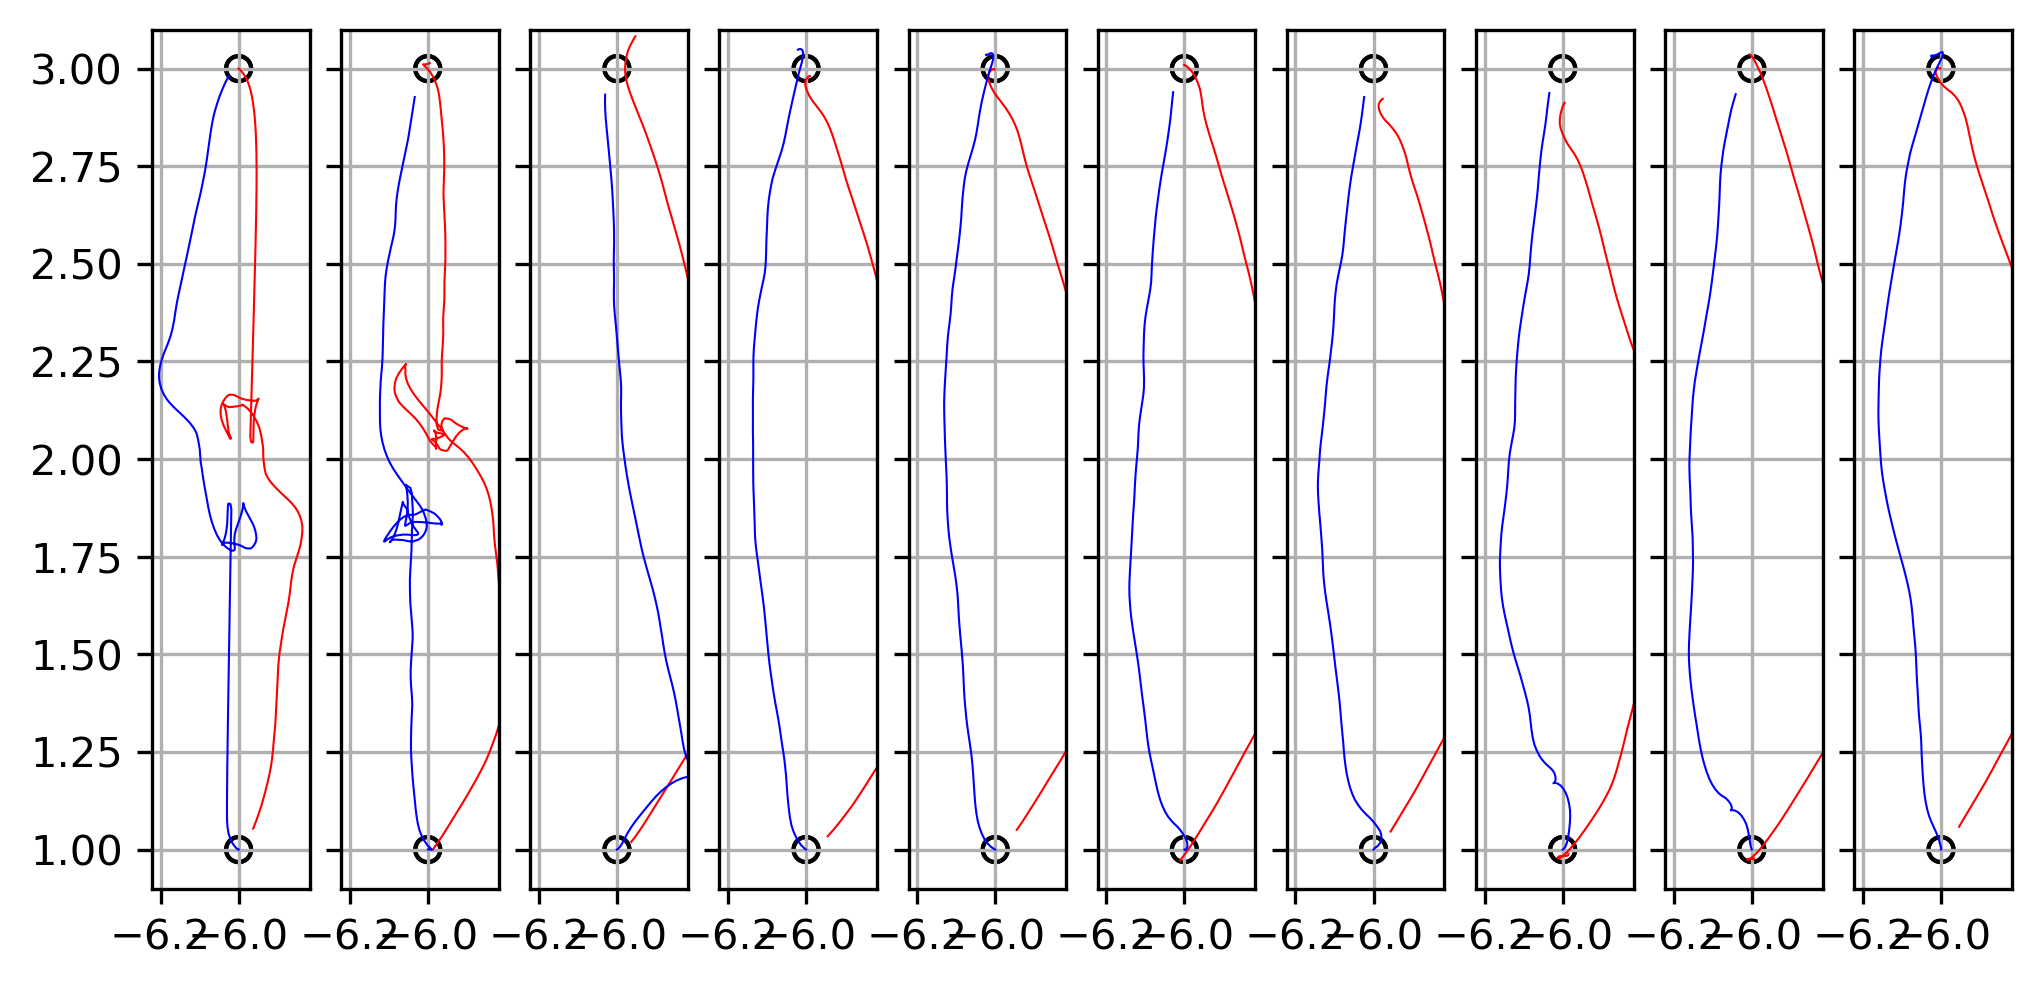

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(8, 8), dpi=300, sharex=True, sharey=True)

ls_color = 'rb'

for trial, ax in enumerate(axes):
    for robot_id, color in zip((1, 2), ls_color):
        model_name = '{}{}'.format(model_names[0], robot_id) 
        x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
        if trial >= -n_trial - 6:
            ax.plot(x, y, 
                    c=color, alpha=1, #(trial + 1 + n_trial) / (n_trial * 2),
                    lw=.5)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    
    for model_name, color in zip(model_names, ls_color):
        ax.plot([], [], c=color, label=model_name)
        ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

    ax.set_aspect('equal')
#     ax.legend()

    floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
    draw_floorplan(ax, floorplan, 0.01)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)    
    ax.grid()
#     ax.set_title(scene_name)

Text(0, 0.5, 'average horitonztal force')

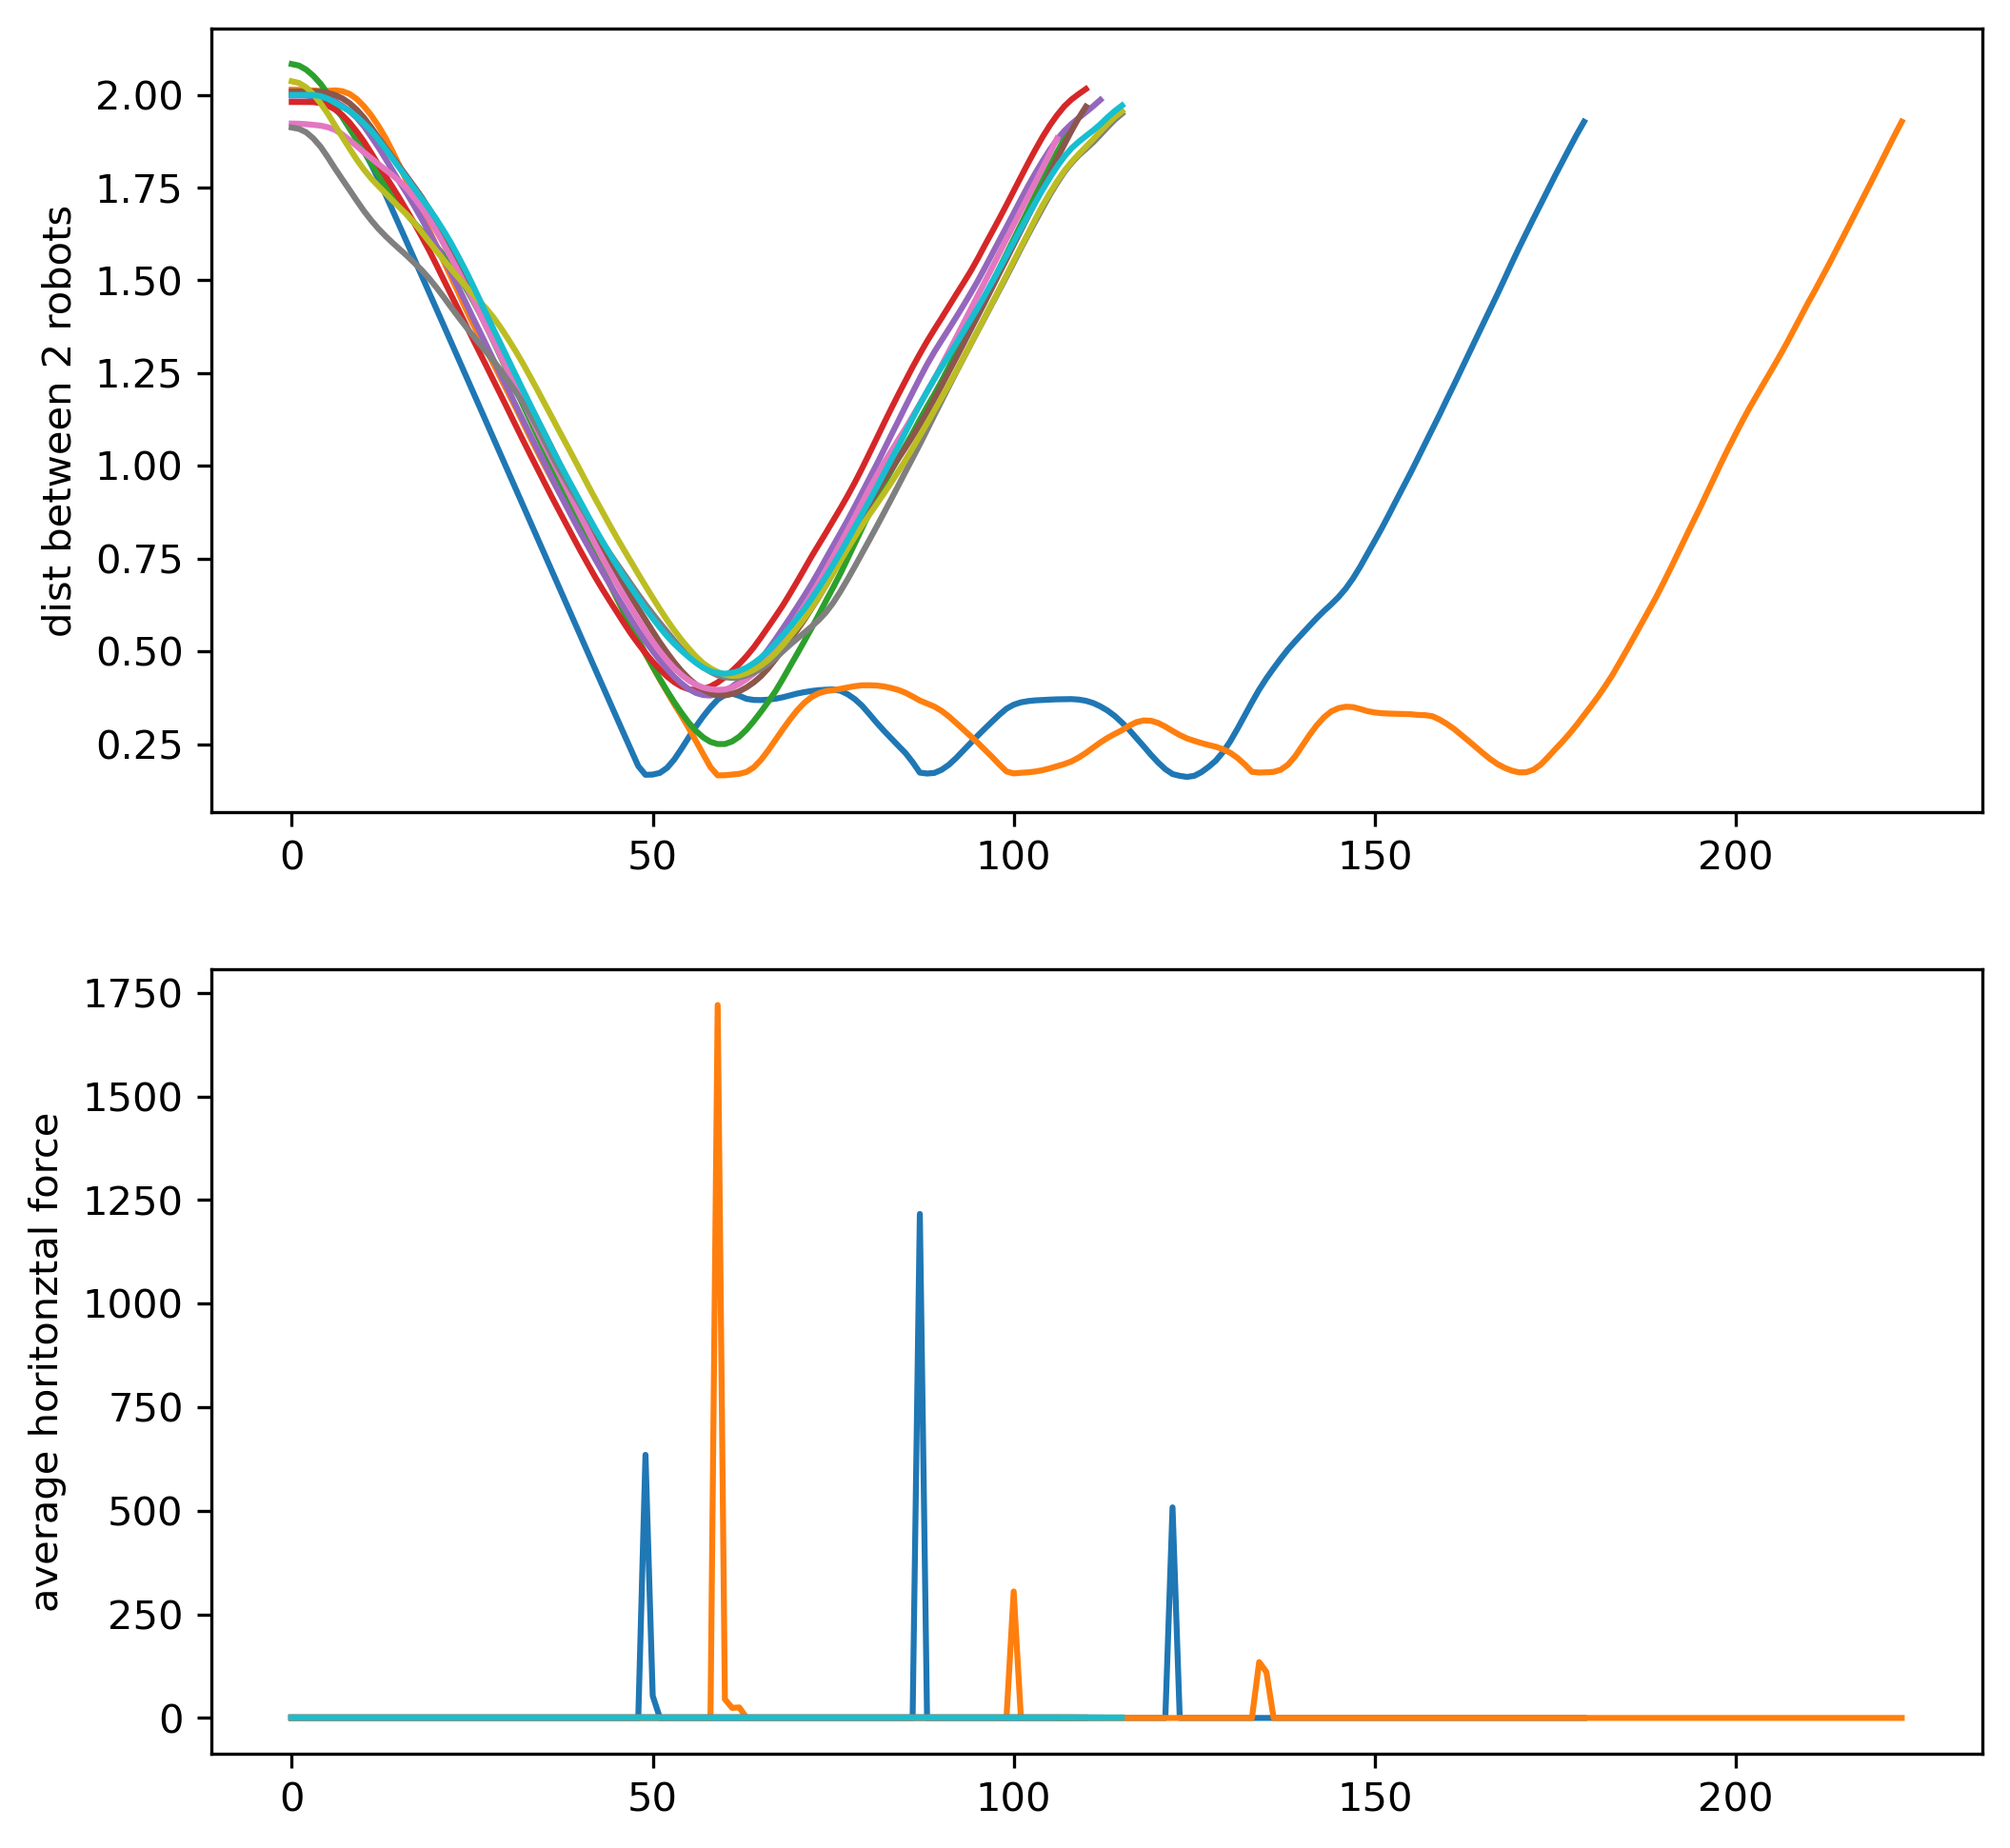

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), dpi=300)

for trial in range(n_trial):
    xy, f = [], []
    for robot_id, color in zip((1, 2), ls_color):
        model_name = '{}{}'.format(model_names[0], robot_id) 
        xy.append([alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]])
        f.append(alldata[model_name]['f'][trial])
    xy = np.array(xy)
    f = np.array(f)
    dist2robot = np.linalg.norm(xy[1] - xy[0], axis=0)
    ax[0].plot(dist2robot)
    ax[1].plot(np.mean(f, axis=0))

ax[0].set_ylabel('dist between 2 robots')
ax[1].set_ylabel('average horitonztal force')

In [7]:
model_names = 'MB4ONdiagonal', 'MB4ONaxial', 'MB2ONbilateral', 'MB2ONopponent'
ls_color = 'tab:red', 'tab:blue', 'tab:orange', 'tab:green'

data_collision = {}
for mn in model_names:
    model_name = '{}1'.format(mn)
    data_collision[model_name] = []

for alldata in repeatdata:
    for mn, color in zip(model_names, ls_color):
        model_name = '{}1'.format(mn) 
        n_collision = [np.count_nonzero(alldata[model_name]['f'][trial] > 100) for trial in range(n_trial)]
        data_collision[model_name].append(n_collision)
        



(-0.5, 10.5)

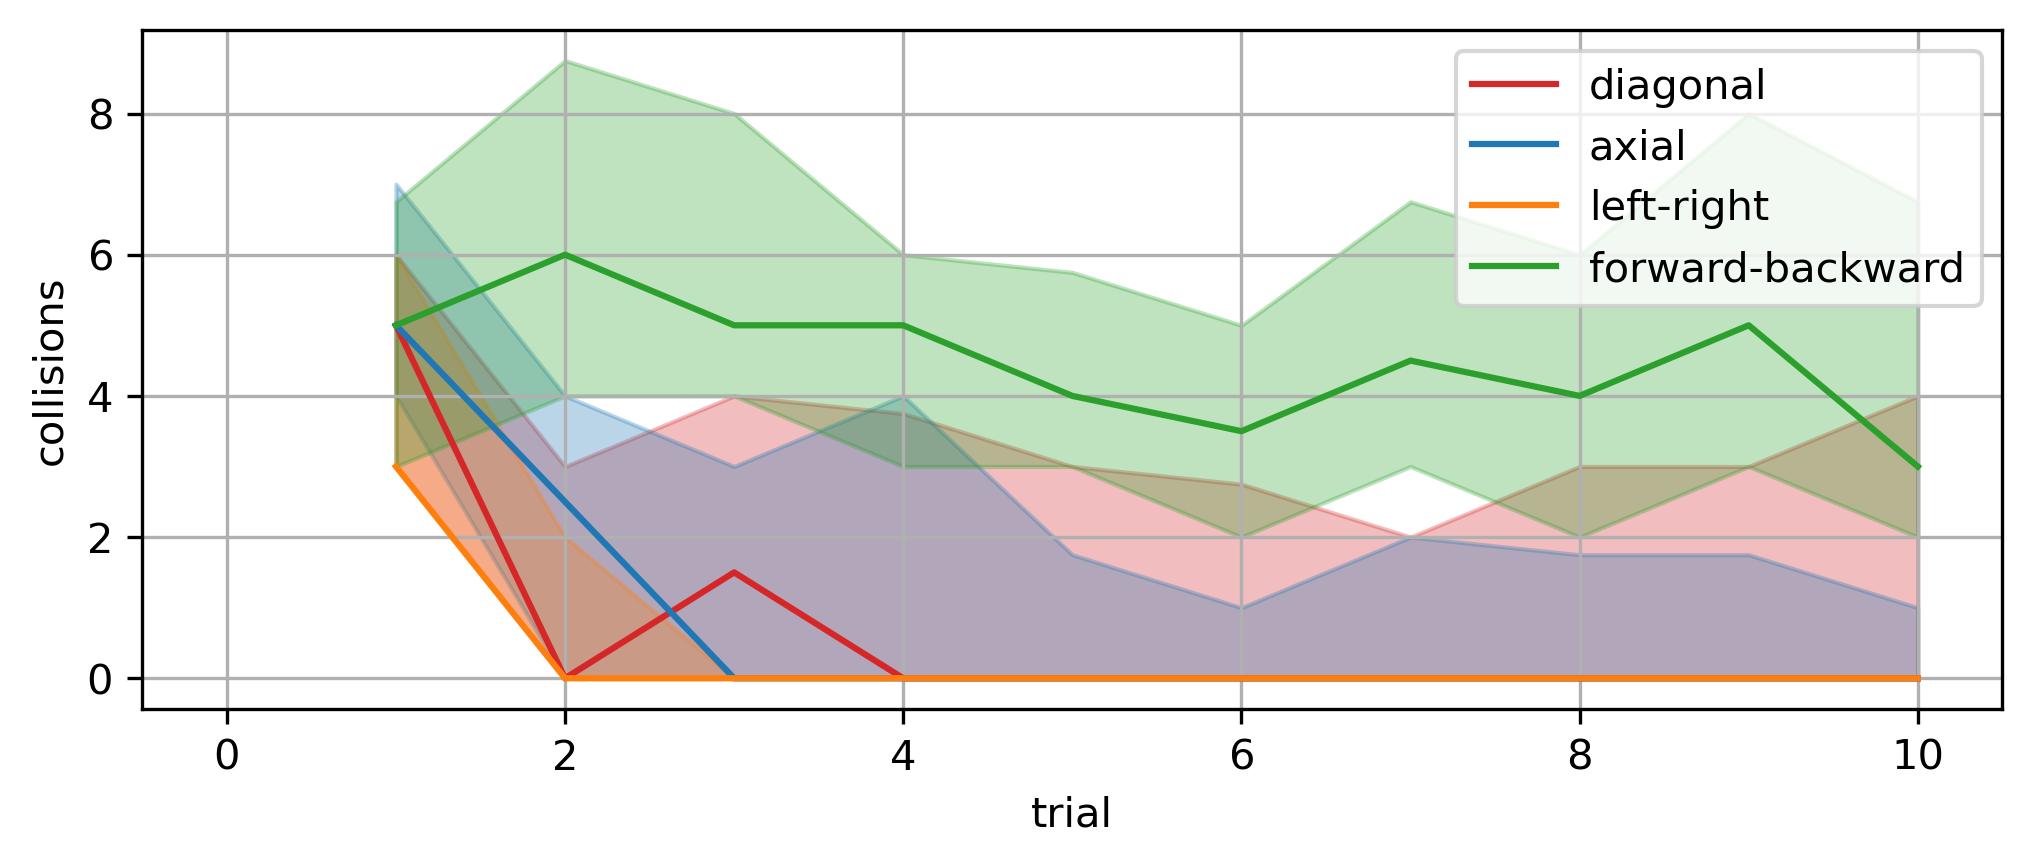

In [8]:
fig, axes = plt.subplots(figsize=(8, 3), dpi=300)


trial_idx = np.arange(n_trial) + 1
for mn, color, lab in zip(model_names, ls_color, ('diagonal', 'axial', 'left-right', 'forward-backward')):
    model_name = '{}1'.format(mn)
    yq = np.quantile(data_collision[model_name], (0.25, 0.5, 0.75), axis=0)
    axes.plot(trial_idx, yq[1], c=color, label=lab)
    axes.fill_between(trial_idx, yq[0], yq[2], color=color, alpha=0.3)
    
axes.grid()
axes.legend()
axes.set_xlabel('trial')
axes.set_ylabel('collisions')
axes.set_xlim(-0.5, 10.5)

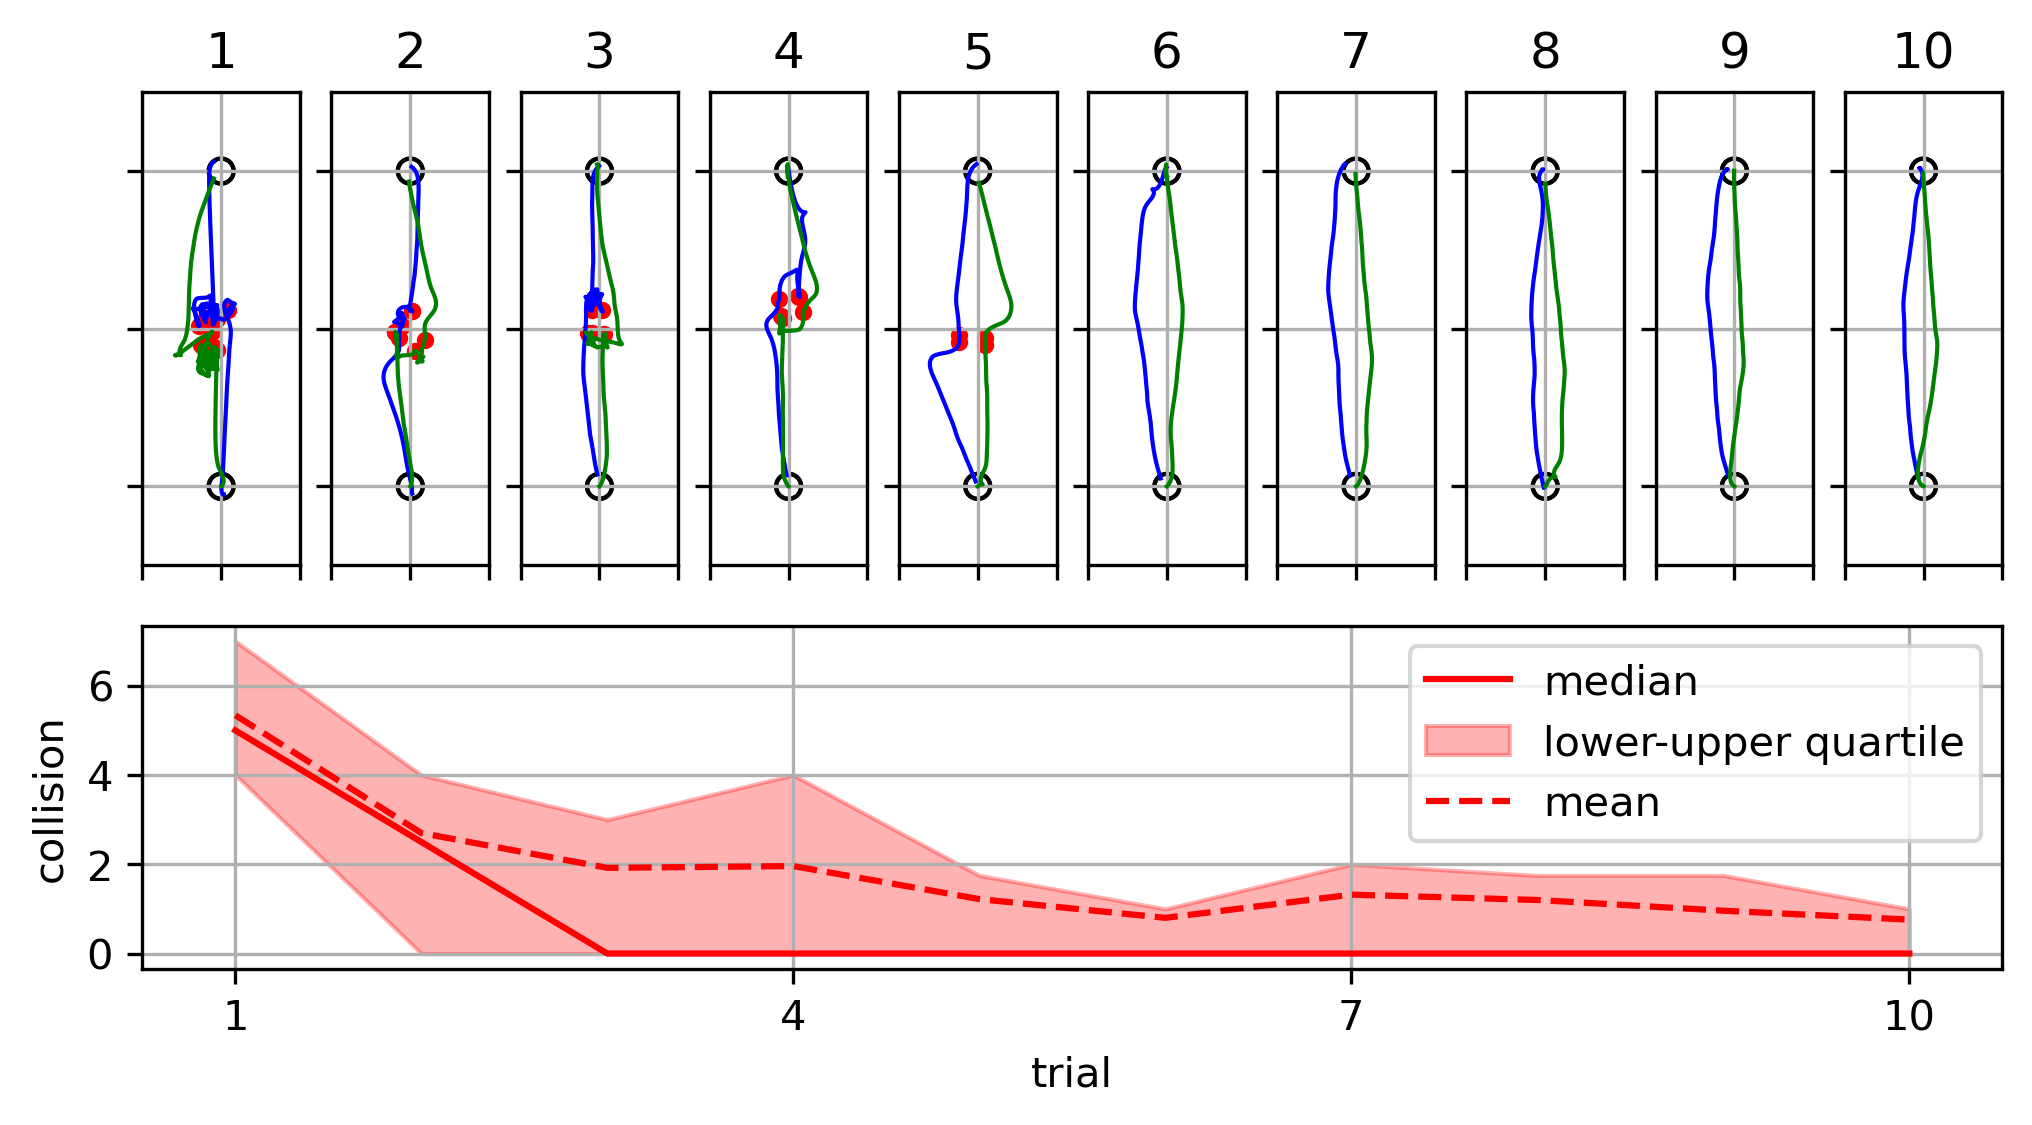

In [68]:
fig, axes = plt.subplot_mosaic('''
                                abcdefghij
                                abcdefghij
                                abcdefghij
                                zzzzzzzzzz
                                zzzzzzzzzz''',
                               figsize=(8, 4), dpi=300)


ls_color = 'bg'
alldata = repeatdata[41] #13, 41, 8, 4, 16, 21, 25, 30, 40

for trial, ak in enumerate('abcdefghij'):
    ax = axes[ak]
    for robot_id, color in zip((1, 2), ls_color):
        model_name = '{}{}'.format(model_names[0], robot_id) 
        x, y, f = [alldata[model_name][arg][trial] for arg in 'xyf']
        ax.plot(x, y, 
                c=color, alpha=1, #(trial + 1 + n_trial) / (n_trial * 2),
                lw=1)
        collision_idx = f > 100
        ax.scatter(x[collision_idx], y[collision_idx], color='r', s=10)
       
    
    
    for model_name, color in zip(model_names, ls_color):
        ax.plot([], [], c=color, label=model_name)
        ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

    ax.set_aspect('equal')
#     ax.legend()

    floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
    draw_floorplan(ax, floorplan, 0.01)
    ax.set_xlim([-6.5, -5.5])
    ax.set_ylim([0.5, 3.5])    
    ax.grid()
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(trial + 1)


trial_idx = np.arange(n_trial) + 1

model_name = 'MB4ONaxial1'
yq = np.quantile(data_collision[model_name], (0.25, 0.5, 0.75), axis=0)
axes['z'].plot(trial_idx, yq[1], c='r', label='median')
axes['z'].fill_between(trial_idx, yq[0], yq[2], color='r', alpha=0.3, label='lower-upper quartile')
axes['z'].plot(trial_idx, np.mean(data_collision[model_name], axis=0), c='r', ls='dashed', label='mean')
    
axes['z'].grid()
axes['z'].set_xlabel('trial')
axes['z'].set_ylabel('collision')
axes['z'].set_xlim(0.5, 10.5)
axes['z'].legend()
axes['z'].set_xticks(np.arange(1, 11, 3))